In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True)

    oof, pred, result_dict = cv_score.score()

    score = np.sqrt(mean_squared_error(y_true=target, y_pred=oof))
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.plot_regression_predictions(data=data, true_label=target, pred_label=oof, feature=["delta_Seed"])

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = np.sqrt(mean_squared_error(y_true=test_target, y_pred=pred))
        print(f"Test score: {score}")
        tml.plot_regression_predictions(data=test_data, true_label=test_target, pred_label=pred, feature=["delta_Seed"])

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/women_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [19]:
result_dict["feat_imp"].head(20)

,mean,std
Feature,,
delta_Seed,204.6,5.081830
delta_N_wins,187.2,53.841666
T2_Seed,178.4,22.390288
T1_Seed,169.6,23.147894
delta_Ast_TO_ratio_diff,144.6,23.419009
delta_Stl_diff,141.6,31.775777
delta_FGM3_perc,132.2,25.229943
delta_off_edge,124.4,34.019480
delta_Score_diff,113.2,8.088572


OOF score: 13.320223168050207
[1435, 1085, 933, 475, 780]


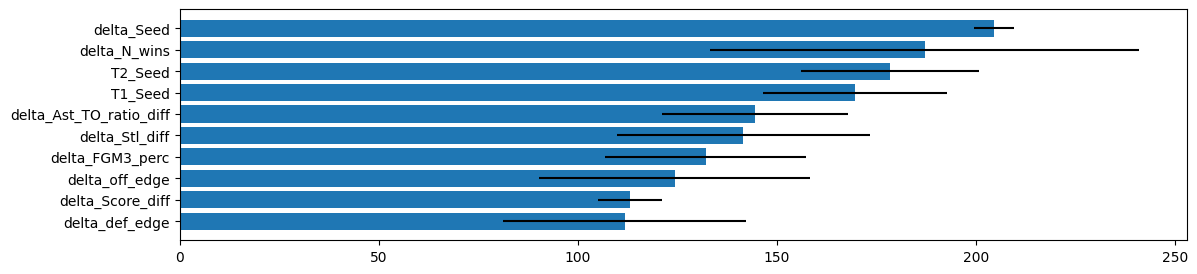

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


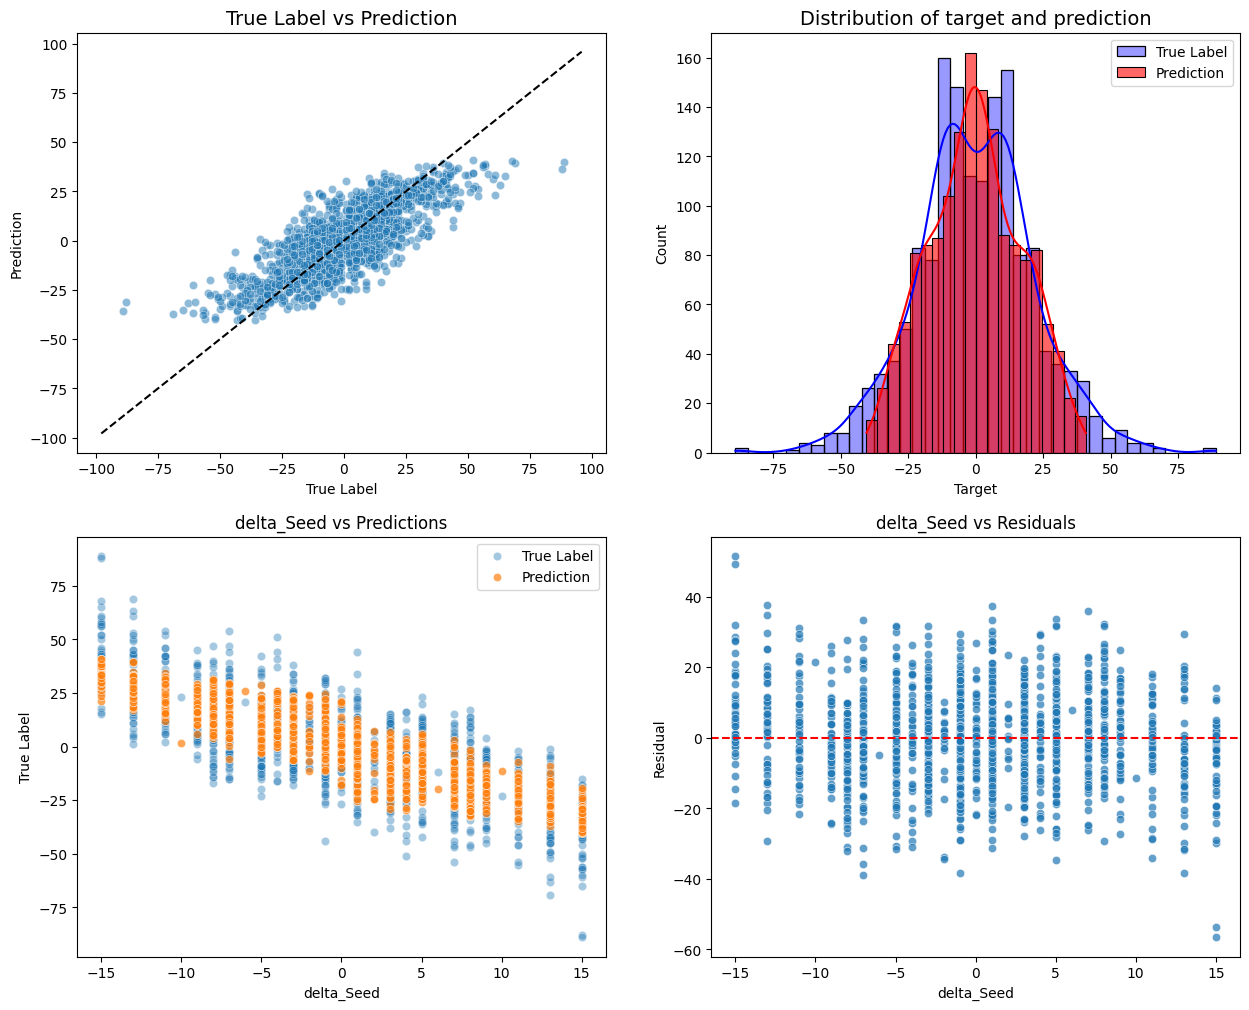

Test score: 13.199548376401333


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


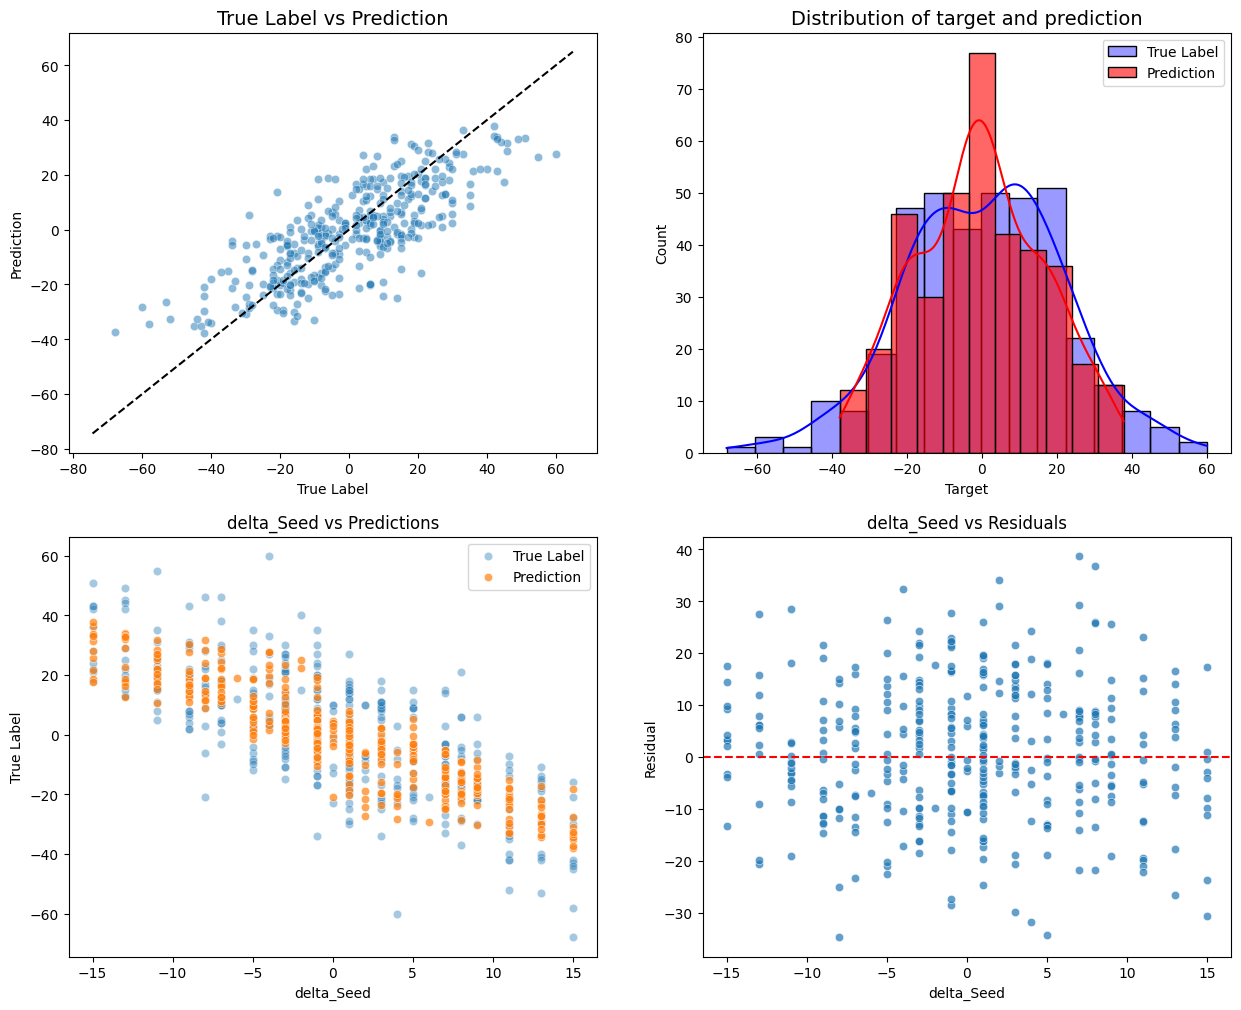

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


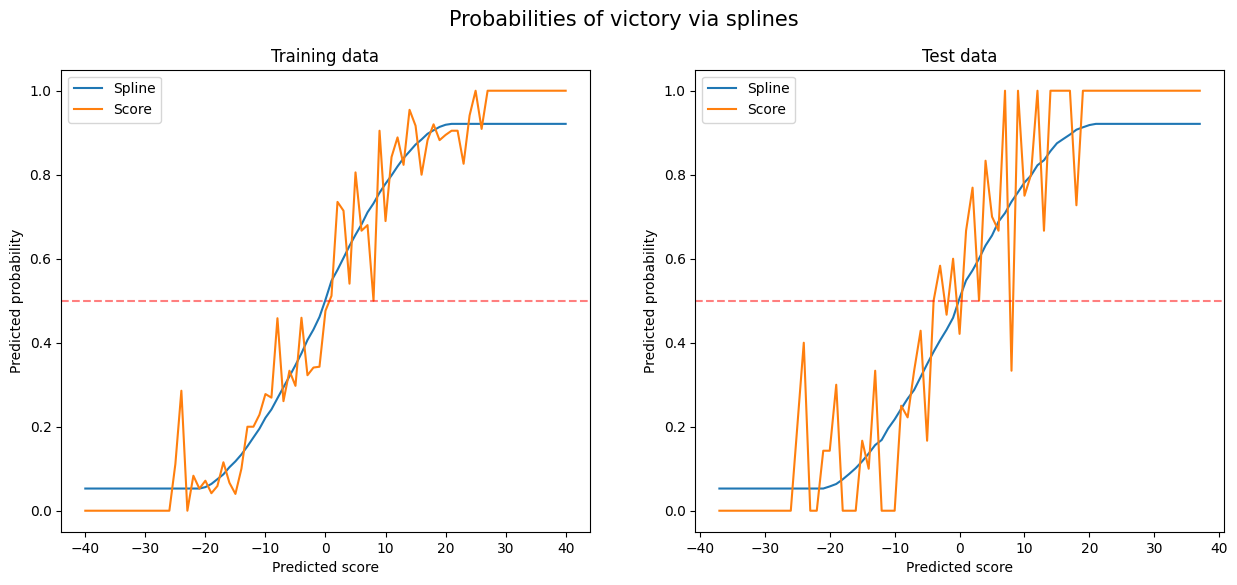

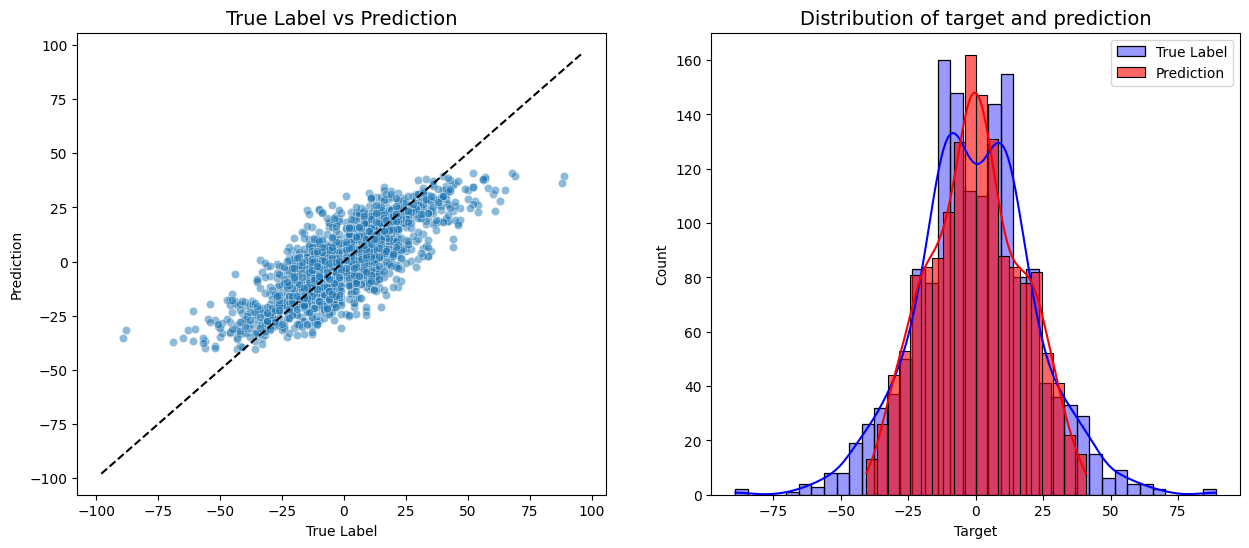

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


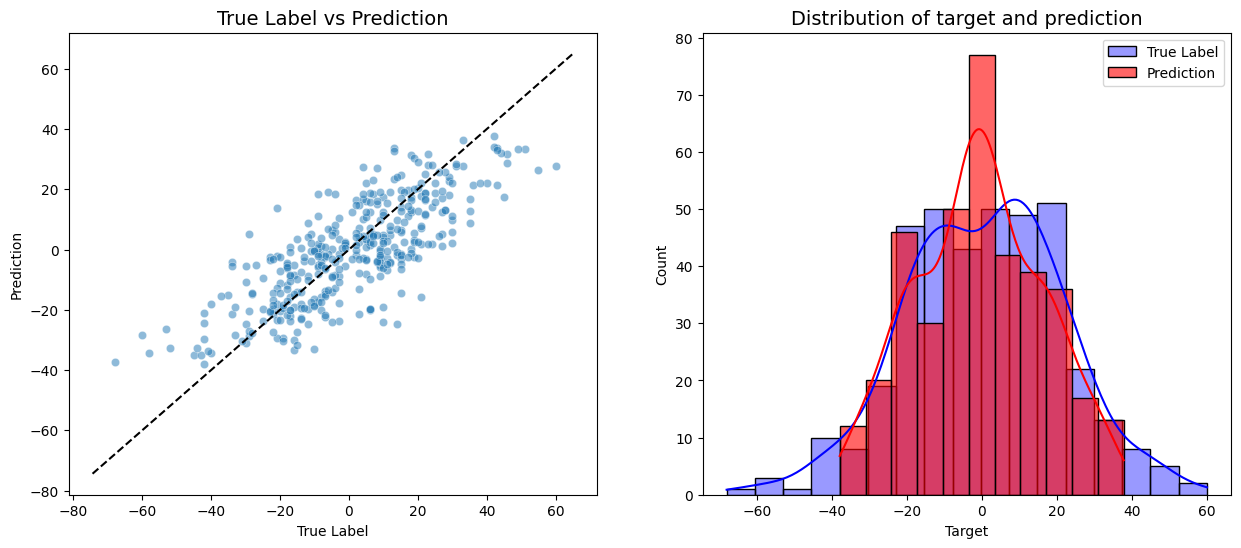

MAE train: 			 10.4732
MAE test: 			 10.6012
RMSE train: 			 13.3202
RMSE test: 			 13.1995
Accuracy train: 		 0.7979
Accuracy test: 			 0.7932
Logloss train: 			 0.4439
Logloss test: 			 0.436
Brier train: 			 0.1439
Brier test: 			 0.1389
Unsure train: 			 10.63%
Unsure test: 			 9.95%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,10.4732,10.6012,13.3202,13.1995,0.7979,0.7932,0.4439,0.436,0.1439,0.1389,10.63,9.95


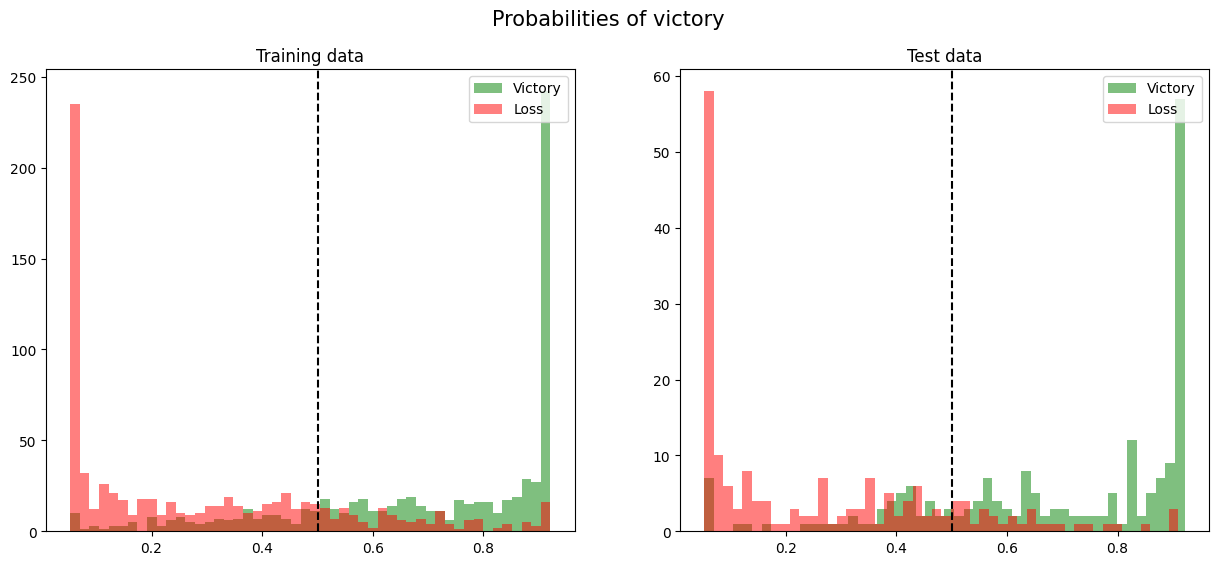

In [18]:
target = df_train["target_points"]

not_imp = [
    'delta_DR_opportunity',
 'delta_FGM_no_ast',
 'delta_OR_opportunity',
 'delta_impact',
 'delta_TO',
    'delta_Stl',
 'delta_opp_PF',
 'delta_PF_diff',
 'delta_possessions',
 'delta_FG3_ratio',
 'delta_FGA3',
 'delta_off_rating_diff',
 'delta_elo',
 'delta_OR',
 'delta_opp_shtg_opportunity',
 'delta_Tot_Reb',
 'delta_FGA3_diff',
 'delta_Eff_FG_perc_diff',
 'delta_FG3_ratio_diff',
 'delta_FGA2',
 'delta_opp_TO',
 'delta_True_shooting_perc',
 'delta_opp_FGM',
 'delta_OR_diff',
 'delta_TO_perposs_diff'
]

extras = ['T1_Seed',
 'T2_Seed',
 "T1_Blk", "T2_Blk"
 ]
FEATURES = [c for c in df_train if "delta" in c and  c not in DROP and c not in not_imp ] + extras
train = df_train[FEATURES].copy()
test_target = df_test["target_points"]
test = df_test[FEATURES].copy()

model = lgb.LGBMRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                          learning_rate=0.01,
                         max_depth=144, num_leaves=53,
                         reg_lambda=8.88, reg_alpha=2.6,
                         colsample_bytree=0.91, subsample=0.83,
                         min_child_weight=192.85, eval_metric="l2", verbose=-1)

pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

callbacks = [lgb.early_stopping(100, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "l2"}

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=False, result_compare=None)


report_points(train=df_train, test=df_test, y_train=target, y_test=test_target, oof=oof, preds=pred, clip_val=21, padd=0.04)

In [20]:
pred_oof, pred_test = _point_to_proba(oof=oof, y_train=df_train["target_points"], preds=pred, clip_val=21, padd=0.04)
df_train["oof"] = oof
df_train["oof_prob"] = pred_oof
df_test ["pred"] = pred
df_test["pred_prob"] = pred_test

df_train["abs_err_points"] = (df_train["target_points"] - df_train["oof"]).abs()
df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["abs_err_points"] = (df_test["target_points"] - df_test["pred"]).abs()
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [21]:
df_train.groupby("stage_Round1")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round1,,
False,10.405270,0.168709
True,10.539796,0.119566


In [22]:
df_train.groupby("stage_Round2")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round2,,
False,10.318157,0.137344
True,10.925384,0.163075


In [23]:
df_train.groupby("stage_Round3")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round3,,
False,10.531912,0.141871
True,10.070302,0.157901


In [24]:
df_train.groupby("stage_Round4")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round4,,
False,10.514257,0.141148
True,9.810374,0.188471


In [25]:
df_train.groupby("stage_finalfour")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_finalfour,,
False,10.501057,0.140878
True,9.512019,0.248385


In [26]:
df_train.groupby("stage_final")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_final,,
False,10.487725,0.144657
True,9.665073,0.102609


In [32]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.14391164840040377
1 0.1439047440674059
2 0.14389201440861324
3 0.14387613180937495
4 0.1438578247227608
5 0.1438391759184516
6 0.14381581633839913
7 0.14379298169272983
8 0.1437668435278613
9 0.14373694004925053
10 0.14370505028547098
11 0.14367394792326627
12 0.14363911908785623
13 0.14361160319600313
14 0.14358640634560946
15 0.14356225936398212
16 0.14353227082019537
17 0.1434948450261688
18 0.14345678728338665
19 0.14341743042234853
20 0.14337851966119367
21 0.14334131493678423
22 0.14330412900851688
23 0.14326672743371371
24 0.14323116312925177


Round1 + 13%
Round4 + 12%
finalfour + 24%
final + 24%


In [33]:
tmp = df_train.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 13 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 + 13 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 13 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 - 13 / 100
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 12 / 100) & (tmp["stage_Round4"]), "oof_prob"] = 0.5 + 12 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 12 / 100) & (tmp["stage_Round4"]), "oof_prob"] = 0.5 - 12 / 100
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 24 / 100) & (tmp["stage_finalfour"]), "oof_prob"] = 0.5 + 24 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 24 / 100) & (tmp["stage_finalfour"]), "oof_prob"] = 0.5 - 24 / 100
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 24 / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 + 24 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 24 / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 - 24 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2
tmp["sqr_err_prob"].mean()


0.14391164840040377


0.14179765651986212

In [34]:
tmp = df_test.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 13 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 + 13 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 13 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 - 13 / 100
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 12 / 100) & (tmp["stage_Round4"]), "pred_prob"] = 0.5 + 12 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 12 / 100) & (tmp["stage_Round4"]), "pred_prob"] = 0.5 - 12 / 100
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 24 / 100) & (tmp["stage_finalfour"]), "pred_prob"] = 0.5 + 24 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 24 / 100) & (tmp["stage_finalfour"]), "pred_prob"] = 0.5 - 24 / 100
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 24 / 100) & (tmp["stage_final"]), "pred_prob"] = 0.5 + 24 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 24 / 100) & (tmp["stage_final"]), "pred_prob"] = 0.5 - 24 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["pred_prob"])**2
tmp["sqr_err_prob"].mean()

0.1388942343153507


0.1406280606449917

In [35]:
df_train.to_csv("data/results/women_train_lgb.csv", index=False)
df_test.to_csv("data/results/women_test_lgb.csv", index=False)